In [145]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
import os
if os.path.exists("medical.db"):
    os.remove("medical.db")
con = duckdb.connect("medical.db")

In [3]:
con.execute("""
SELECT *
FROM read_csv_auto('C:/Users/ishum/Downloads/mdrfoithru2025.txt', delim='|', ignore_errors=true)
LIMIT 5
""").df()

,MDR_REPORT_KEY,EVENT_KEY,REPORT_NUMBER,REPORT_SOURCE_CODE,MANUFACTURER_LINK_FLAG_,NUMBER_DEVICES_IN_EVENT,NUMBER_PATIENTS_IN_EVENT,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,...,DATE_ADDED,DATE_CHANGED,REPORTER_STATE_CODE,REPORTER_COUNTRY_CODE,PMA_PMN_NUM,EXEMPTION_NUMBER,SUMMARY_REPORT,NOE_SUMMARIZED,SUPPL_DATES_FDA_RECEIVED,SUPPL_DATES_MFR_RECEIVED
0,23938784,None,3019004087-2025-18390,M,Y,None,None,2025-12-31,Y,N,...,2026-01-01,2026-01-02,None,US,K231485,None,N,1,None,None
1,23938783,None,3004753838-2025-353235,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,OH,US,K213919,None,N,1,None,None
2,23938782,None,3004753838-2025-353234,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,JP,K213919,None,N,1,None,None
3,23938781,None,3004753838-2025-353231,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,DE,K213919,None,N,1,None,None
4,23938780,None,3004753838-2025-353232,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,CA,K213919,None,N,1,None,None


In [4]:
con.execute("""DROP TABLE IF EXISTS mdr""")
con.execute("""CREATE TABLE mdr AS select * from read_csv_auto('C:/Users/ishum/Downloads/mdrfoithru2025.txt', delim='|', ignore_errors=true, strict_mode=false)""")

In [5]:
con.execute("""
SELECT * from mdr limit 10 """).df()

,MDR_REPORT_KEY,EVENT_KEY,REPORT_NUMBER,REPORT_SOURCE_CODE,MANUFACTURER_LINK_FLAG_,NUMBER_DEVICES_IN_EVENT,NUMBER_PATIENTS_IN_EVENT,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,...,DATE_ADDED,DATE_CHANGED,REPORTER_STATE_CODE,REPORTER_COUNTRY_CODE,PMA_PMN_NUM,EXEMPTION_NUMBER,SUMMARY_REPORT,NOE_SUMMARIZED,SUPPL_DATES_FDA_RECEIVED,SUPPL_DATES_MFR_RECEIVED
0,23938784,None,3019004087-2025-18390,M,Y,None,None,2025-12-31,Y,N,...,2026-01-01,2026-01-02,None,US,K231485,None,N,1,None,None
1,23938783,None,3004753838-2025-353235,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,OH,US,K213919,None,N,1,None,None
2,23938782,None,3004753838-2025-353234,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,JP,K213919,None,N,1,None,None
3,23938781,None,3004753838-2025-353231,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,DE,K213919,None,N,1,None,None
4,23938780,None,3004753838-2025-353232,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,CA,K213919,None,N,1,None,None
5,23938779,None,2954323-2025-52363,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,None,K233537,None,N,1,None,None
6,23938778,None,2954323-2025-52361,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,GM,K223435,None,N,1,None,None
7,23938777,None,2954323-2025-52362,M,Y,None,None,2025-12-31,N,Y,...,2026-01-01,2026-01-05,None,None,K223435,None,N,1,None,None
8,23938776,None,3019004087-2025-18388,M,Y,None,None,2025-12-31,N,N,...,2026-01-01,2026-01-06,None,US,K231485,None,N,1,None,None
9,23938775,None,3019004087-2025-18383,M,Y,None,None,2025-12-31,N,N,...,2026-01-01,2026-01-07,None,US,K231485,None,N,1,None,None


In [6]:
con.execute(""" create or replace table device as select * from read_csv_auto('C:/Users/ishum/Downloads/DEVICE2025.txt', delim='|', ignore_errors=true, strict_mode=false)""")

In [7]:
con.execute("""
SELECT * from device limit 10 """).df()

,MDR_REPORT_KEY,DEVICE_EVENT_KEY,IMPLANT_FLAG,DATE_REMOVED_FLAG,DEVICE_SEQUENCE_NO,IMPLANT_DATE_YEAR,DATE_REMOVED_YEAR,SERVICED_BY_3RD_PARTY_FLAG,DATE_RECEIVED,BRAND_NAME,...,LOT_NUMBER,OTHER_ID_NUMBER,DEVICE_AVAILABILITY,DATE_RETURNED_TO_MANUFACTURER,DEVICE_REPORT_PRODUCT_CODE,DEVICE_AGE_TEXT,DEVICE_EVALUATED_BY_MANUFACTUR,COMBINATION_PRODUCT_FLAG,UDI-DI,UDI-PUBLIC
0,21050632,None,None,None,2054423,<NA>,<NA>,None,2025-01-01,"CARDIOSAVE HYBRID, TYPE G PLUG",...,None,None,Y,NaT,DSP,DA,Y,N,10607567108438,(01)10607567108438
1,21050633,None,None,None,2054424,<NA>,<NA>,None,2025-01-01,"CARDIOSAVE HYBRID, TYPE B PLUG",...,None,None,Y,NaT,DSP,DA,Y,N,10607567108391,(01)10607567108391
2,21050634,None,None,None,2054425,<NA>,<NA>,None,2025-01-01,MINIMED 780G US SYSTEM BLE CONNECT 3.0 MG/DL,...,NG3581694H,None,N,NaT,OZP,None,*,N,None,None
3,21050635,None,None,None,2054426,<NA>,<NA>,None,2025-01-01,DREAMSTATION AUTO CPAP,...,None,None,R,NaT,BZD,DA,Y,N,00606959051515,(01)00606959051515
4,21050636,None,None,None,2054427,<NA>,<NA>,Y,2025-01-01,DREAMSTATION AUTO CPAP,...,None,None,N,NaT,BZD,DA,N,N,00606959424173,(01)00606959424173
5,21050637,None,None,None,2054428,<NA>,<NA>,U,2025-01-01,MCGRATH MAC,...,None,None,R,NaT,CCW,DA,Y,N,10884521823396,10884521823396
6,21050638,None,None,None,2054429,<NA>,<NA>,None,2025-01-01,"CARDIOSAVE HYBRID, TYPE I PLUG",...,None,None,Y,NaT,DSP,DA,Y,N,10607567108421,(01)10607567108421
7,21050639,None,None,None,2054430,<NA>,<NA>,N,2025-01-01,RUNTHROUGH,...,None,None,N,NaT,DQX,None,*,N,04987350734709,(01)04987350734709
8,21050640,None,None,None,2054431,<NA>,<NA>,N,2025-01-01,RUNTHROUGH,...,None,None,N,NaT,DQX,None,N,N,04987350734709,(01)04987350734709
9,21050641,None,None,None,2054432,<NA>,<NA>,U,2025-01-01,SINGLE USE GUIDEWIRE,...,43K,None,R,NaT,OCY,DA,N,N,04953170358241,(01)04953170358241


In [8]:
con.execute(""" create or replace table text_data as select * from read_csv_auto('C:/Users/ishum/Downloads/foitext2025.txt', delim='|', ignore_errors=true, strict_mode=false)""")

In [9]:
df = con.execute("""
SELECT FOI_TEXT
FROM text_data
LIMIT 1
""").df()

print(df['FOI_TEXT'][0])

INTUITIVE SURGICAL, INC. (ISI) RECEIVED A DA VINCI PRODUCT TO PERFORM A FAILURE ANALYSIS. THE FENESTRATED BIPOLAR FORCEPS INSTRUMENT WAS ANALYZED AND FOUND TO HAVE CHARRING AND/OR LOCALIZED MELTING ON THE OUTER SURFACE OF ONE BIPOLAR YAW PULLEY AT THE BASE OF THE GRIP. AS A RESULT OF THE DAMAGE, A SECTION OF THE ACTIVE ELECTRODE (GRIP) WAS EXPOSED THAT WOULD NOT NORMALLY BE EXPOSED. THE INSTRUMENT PASSED THE ELECTRICAL CONTINUITY TEST. A REVIEW OF THE PROCEDURE LOGS INDICATED THAT A MONOPOLAR INSTRUMENT WAS USED DURING THIS CASE. THE COMPLAINT WAS CONFIRMED BY FAILURE ANALYSIS, WHICH INDICATES THAT THE DEVICE MAY HAVE CONTRIBUTED TO THE CUSTOMER-REPORTED ISSUE.


In [10]:
con.execute(""" create or replace  table patient as select * from read_csv_auto('C:/Users/ishum/Downloads/patientThru2025.txt', delim='|', ignore_errors=true, strict_mode=false)""")

In [11]:
con.execute("""
SELECT * from patient order by DATE_RECEIVED desc limit 1000""").df()

,MDR_REPORT_KEY,PATIENT_SEQUENCE_NUMBER,DATE_RECEIVED,SEQUENCE_NUMBER_TREATMENT,SEQUENCE_NUMBER_OUTCOME,PATIENT_AGE,PATIENT_SEX,PATIENT_WEIGHT,PATIENT_ETHNICITY,PATIENT_RACE
0,23931679,1,2025-12-31,None,None,40 YR,Male,<NA>,None,None
1,23931762,1,2025-12-31,None,None,NA,Unknown,<NA>,None,None
2,23931681,1,2025-12-31,None,None,62 YR,Male,<NA>,None,None
3,23932364,1,2025-12-31,None,None,NA,Unknown,<NA>,None,None
4,23931755,1,2025-12-31,None,L,68 YR,Unknown,<NA>,None,None
...,...,...,...,...,...,...,...,...,...,...
995,23931967,1,2025-12-31,None,None,NA,Unknown,<NA>,None,None
996,23931888,1,2025-12-31,NOT PROVIDED.,R,NA,Unknown,<NA>,None,None
997,23932220,1,2025-12-31,None,None,NA,Unknown,<NA>,None,None
998,23932711,1,2025-12-31,None,None,9 YR,Male,<NA>,None,None


In [12]:
con.execute(""" create or replace table mdr_recent as
SELECT * from mdr where DATE_RECEIVED > '2020-01-01' order by DATE_RECEIVED """)

In [13]:
con.execute(""" SELECT 
            count(*) as total_complaints,
            count(distinct MDR_REPORT_KEY) as unique_reports
            from patient""").df()

,total_complaints,unique_reports
0,20450193,20442308


In [14]:
con.execute("""
SELECT  distinct MDR_REPORT_KEY ,count(*) as cnt from patient group by MDR_REPORT_KEY order by cnt desc limit 15""").df()

,MDR_REPORT_KEY,cnt
0,1513194,52
1,758931,48
2,1079268,43
3,1006903,34
4,1900264,34
5,1059354,29
6,1006137,25
7,1362312,24
8,1749403,23
9,1338352,23


In [15]:
con.execute("""
SELECT * from patient where MDR_REPORT_KEY = '1513194'""").df()

,MDR_REPORT_KEY,PATIENT_SEQUENCE_NUMBER,DATE_RECEIVED,SEQUENCE_NUMBER_TREATMENT,SEQUENCE_NUMBER_OUTCOME,PATIENT_AGE,PATIENT_SEX,PATIENT_WEIGHT,PATIENT_ETHNICITY,PATIENT_RACE
0,1513194,1,2009-10-13,None,None,UNK,None,<NA>,None,None
1,1513194,2,2009-10-13,None,None,UNK,None,<NA>,None,None
2,1513194,3,2009-10-13,None,None,UNK,None,<NA>,None,None
3,1513194,4,2009-10-13,None,None,UNK,None,<NA>,None,None
4,1513194,5,2009-10-13,None,None,UNK,None,<NA>,None,None
5,1513194,6,2009-10-13,None,None,UNK,None,<NA>,None,None
6,1513194,7,2009-10-13,None,None,UNK,None,<NA>,None,None
7,1513194,8,2009-10-13,None,None,UNK,None,<NA>,None,None
8,1513194,9,2009-10-13,None,None,UNK,None,<NA>,None,None
9,1513194,10,2009-10-13,None,None,UNK,None,<NA>,None,None


In [16]:
con.execute("""
SELECT sum( case when PATIENT_AGE is null 
            or PATIENT_AGE ='unk'
            or PATIENT_AGE='NA' then 1 else 0 end ) *100 / count(*) as missing_age_perct,
            sum( case when PATIENT_SEX is null
            or PATIENT_SEX='unk' or PATIENT_SEX='NA' then 1 else 0 end )*100 /count(*) as missing_sex_perct
            from patient""").df()

,missing_age_perct,missing_sex_perct
0,49.165027,54.320231


In [17]:
con.execute(""" create or replace table patient_summary as 
SELECT MDR_REPORT_KEY,
        MAX(
        CASE 
            WHEN SEQUENCE_NUMBER_OUTCOME = 'D' THEN 5
            WHEN SEQUENCE_NUMBER_OUTCOME = 'L' THEN 4
            WHEN SEQUENCE_NUMBER_OUTCOME = 'R' THEN 3
            WHEN SEQUENCE_NUMBER_OUTCOME = 'I' THEN 2
            WHEN SEQUENCE_NUMBER_OUTCOME = 'O' THEN 1
            ELSE 0
        END
    ) as max_severity_score,
       AVG(CASE
             WHEN TRY_CAST(REPLACE(PATIENT_AGE,'YR','') AS DOUBLE) IS NOT NULL
             THEN CAST(REPLACE(PATIENT_AGE,'YR','') AS DOUBLE)
           END) as avg_patient_age
FROM patient
GROUP BY MDR_REPORT_KEY """)

In [18]:
con.execute(""" SELECT * from patient_summary""").df()

,MDR_REPORT_KEY,max_severity_score,avg_patient_age
0,795623,0,NaN
1,796087,0,47.0
2,796136,0,25.0
3,796221,0,NaN
4,796386,0,38.0
...,...,...,...
20442303,22670737,0,NaN
20442304,22670990,0,14.0
20442305,22671020,3,61.0
20442306,22671440,3,58.0


In [32]:
con.execute("""
CREATE OR REPLACE TABLE device_summary AS
SELECT
    MDR_REPORT_KEY,
    COUNT(*) as num_devices,
    
    STRING_AGG(DISTINCT MANUFACTURER_D_NAME, ', ') as manufacturers,
    
    STRING_AGG(DISTINCT BRAND_NAME, ', ') as all_brands,
    
    STRING_AGG(DISTINCT DEVICE_REPORT_PRODUCT_CODE, ', ') as all_product_codes

FROM device
GROUP BY MDR_REPORT_KEY
""")

In [22]:
con.execute("""
SELECT * from device_summary """).df()

,MDR_REPORT_KEY,num_devices,all_brands,all_product_codes
0,21917537,1,MINIMED 780G OUS SYSTEM BLE CONNECT 3.0 MMOL/L,OZP
1,21917542,1,ALARIS SYSTEM,FRN
2,21917563,1,SENSOR MMT-7020C1 GS3 5PK 9L OUS1,OZP
3,21917601,1,PUMP 1886 780G OUS BLE PUMP MG/DL,OZP
4,21917660,1,MINIMED 780G OUS SYSTEM BLE CONNECT 3.0 MMOL/L,OZP
...,...,...,...,...
2191441,23682240,1,EVIS EXERA III GASTROINTESTINAL VIDEOSCOPE,FDS
2191442,23682252,1,VCL+ UD 36IN 2-0 S/A CTB-1,GAM
2191443,23682272,1,ALLURA XPER FD,IZI
2191444,23682297,1,COLONOVIDEOSCOPE,FDF


In [26]:
con.execute("""
SELECT count(*) as cnt,MANUFACTURER_NAME from final_complaints GROUP BY MANUFACTURER_NAME """).df()

,cnt,MANUFACTURER_NAME
0,16845332,None


In [27]:
con.execute("""
DESCRIBE mdr
""").df()

,column_name,column_type,null,key,default,extra
0,MDR_REPORT_KEY,BIGINT,YES,None,None,None
1,EVENT_KEY,VARCHAR,YES,None,None,None
2,REPORT_NUMBER,VARCHAR,YES,None,None,None
3,REPORT_SOURCE_CODE,VARCHAR,YES,None,None,None
4,MANUFACTURER_LINK_FLAG_,VARCHAR,YES,None,None,None
...,...,...,...,...,...,...
81,EXEMPTION_NUMBER,VARCHAR,YES,None,None,None
82,SUMMARY_REPORT,VARCHAR,YES,None,None,None
83,NOE_SUMMARIZED,BIGINT,YES,None,None,None
84,SUPPL_DATES_FDA_RECEIVED,VARCHAR,YES,None,None,None


In [39]:
con.execute("""
DESCRIBE device_summary
""").df()

,column_name,column_type,null,key,default,extra
0,MDR_REPORT_KEY,BIGINT,YES,None,None,None
1,num_devices,BIGINT,YES,None,None,None
2,manufacturers,VARCHAR,YES,None,None,None
3,all_brands,VARCHAR,YES,None,None,None
4,all_product_codes,VARCHAR,YES,None,None,None


In [38]:
con.execute("""
DESCRIBE PATIENT_SUMMARY
""").df()

,column_name,column_type,null,key,default,extra
0,MDR_REPORT_KEY,BIGINT,YES,None,None,None
1,max_severity_score,INTEGER,YES,None,None,None
2,avg_patient_age,DOUBLE,YES,None,None,None


In [62]:
con.execute("""
CREATE OR REPLACE TABLE final_complaints AS
SELECT

    m.MDR_REPORT_KEY,
    m.DATE_RECEIVED,    

    m.ADVERSE_EVENT_FLAG,
    m.PRODUCT_PROBLEM_FLAG,
    m.REPORT_SOURCE_CODE,
    m.REPORTER_COUNTRY_CODE,

    d.num_devices,
    d.manufacturers,
    d.all_brands,
    d.all_product_codes,

    p.max_severity_score,
    p.avg_patient_age,

    t.FOI_TEXT AS complaint_text

FROM mdr_recent m

LEFT JOIN device_summary d
ON m.MDR_REPORT_KEY = d.MDR_REPORT_KEY

LEFT JOIN patient_summary p
ON m.MDR_REPORT_KEY = p.MDR_REPORT_KEY

LEFT JOIN text_data t
ON m.MDR_REPORT_KEY = t.MDR_REPORT_KEY
""")

In [36]:
con.execute("""
COPY final_complaints
TO 'C:/Users/ishum/OneDrive/Desktop/Healthcare analytics/final_complaints.csv'
WITH (HEADER, DELIMITER ',')
""")

In [63]:
con.execute("""
SELECT *from final_complaints  limit 20""").df()

,MDR_REPORT_KEY,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,REPORT_SOURCE_CODE,REPORTER_COUNTRY_CODE,num_devices,manufacturers,all_brands,all_product_codes,max_severity_score,avg_patient_age,complaint_text
0,9659370,2020-02-03,N,Y,U,None,<NA>,None,None,None,1,NaN,None
1,9659369,2020-02-03,Y,N,M,None,<NA>,None,None,None,3,73.0,None
2,9659368,2020-02-03,N,Y,M,None,<NA>,None,None,None,0,NaN,None
3,9659367,2020-02-03,Y,N,M,None,<NA>,None,None,None,3,NaN,None
4,9659366,2020-02-03,Y,N,M,None,<NA>,None,None,None,3,NaN,None
5,9659365,2020-02-03,Y,N,M,None,<NA>,None,None,None,0,75.0,None
6,9659364,2020-02-03,Y,N,M,None,<NA>,None,None,None,0,68.0,None
7,9659363,2020-02-03,Y,N,M,None,<NA>,None,None,None,0,NaN,None
8,9659362,2020-02-03,Y,N,M,None,<NA>,None,None,None,3,NaN,None
9,9659361,2020-02-03,Y,N,M,None,<NA>,None,None,None,3,NaN,None


In [51]:

con.execute("""
SELECT *from mdr_recent  where MDR_REPORT_KEY= '9544014' """).df()




,MDR_REPORT_KEY,EVENT_KEY,REPORT_NUMBER,REPORT_SOURCE_CODE,MANUFACTURER_LINK_FLAG_,NUMBER_DEVICES_IN_EVENT,NUMBER_PATIENTS_IN_EVENT,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,...,DATE_ADDED,DATE_CHANGED,REPORTER_STATE_CODE,REPORTER_COUNTRY_CODE,PMA_PMN_NUM,EXEMPTION_NUMBER,SUMMARY_REPORT,NOE_SUMMARIZED,SUPPL_DATES_FDA_RECEIVED,SUPPL_DATES_MFR_RECEIVED
0,9544014,None,MW5092020,P,N,None,None,2020-01-02,Y,N,...,2020-01-03,2025-07-24,None,None,None,None,N,1,None,None


In [56]:
con.execute("""
SELECT count(*) as cnt , sum(case when d.MDR_REPORT_KEY is null then 1 else 0 end) as missing_report_key_cnt,sum(case when d.MDR_REPORT_KEY is null then 1 else 0 end)*100/count(*) as missing_report_key_percentage from mdr_recent m left join device_summary d on m.MDR_REPORT_KEY = d.MDR_REPORT_KEY""").df()

,cnt,missing_report_key_cnt,missing_report_key_percentage
0,13840960,11656501.0,84.217431


In [57]:
con.execute("""
SELECT 
    COUNT(*) as total_device_rows,
    COUNT(DISTINCT MDR_REPORT_KEY) as unique_reports_in_device
FROM device
""").df()

,total_device_rows,unique_reports_in_device
0,2191446,2191446


In [65]:
con.execute("""  Create or replace table Device_complaints as select * from final_complaints where manufacturers is not null """).df()

,Count
0,4784156


In [66]:
con.execute("""
SELECT * from device_complaints limit 20""").df()

,MDR_REPORT_KEY,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,REPORT_SOURCE_CODE,REPORTER_COUNTRY_CODE,num_devices,manufacturers,all_brands,all_product_codes,max_severity_score,avg_patient_age,complaint_text
0,22263597,2025-06-18,Y,N,M,SP,1,JJGC S.A.,"GM HELIX IMPLANT,TI,3.75X11.5",DZE,3,NaN,THE BATCH NUMBER COULD NOT BE VERIFIED DUE TO ...
1,22263596,2025-06-18,Y,N,M,SP,1,JJGC S.A.,"GM HELIX ACQUA IMPLANT,TI,4.0X8",DZE,3,46.0,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
2,22263595,2025-06-18,Y,N,M,TU,1,JJGC S.A.,CM ALVIM IMPL TI 4.3X8,DZE,3,NaN,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
3,22263594,2025-06-18,Y,N,M,SP,1,JJGC S.A.,"GM HELIX IMPLANT,TI,4.3X8",DZE,3,NaN,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
4,22263593,2025-06-18,Y,N,M,TU,1,JJGC S.A.,"GM HELIX IMPLANT,TI,3.75X10",DZE,3,NaN,THE BATCH NUMBER COULD NOT BE VERIFIED DUE TO ...
5,22263592,2025-06-18,Y,N,M,US,1,JJGC S.A.,"GM HELIX ACQUA IMPLANT,TI,5.0X10",DZE,3,56.0,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
6,22263591,2025-06-18,Y,N,M,SP,1,JJGC S.A.,"GM HELIX ACQUA IMPLANT,TI,3.75X10",DZE,3,NaN,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
7,22263590,2025-06-18,Y,N,M,None,1,MIS IMPLANTS TECHNOLOGIES LTD.,SEVEN INTERNAL HEX. IMPLANT DIA. 4.20 L 8MM,DZE,3,NaN,"SINCE THIS EVENT RESULTED IN A SERIOUS INJURY,..."
8,22263589,2025-06-18,Y,N,M,FR,1,JJGC S.A.,"GM HELIX IMPLANT,TI,3.5X11.5",DZE,3,44.0,THE BATCH NUMBER COULD BE VERIFIED. OUR MANUFA...
9,22263588,2025-06-18,Y,N,M,TU,1,JJGC S.A.,"GM HELIX IMPLANT,TI,3.75X10",DZE,3,NaN,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...


In [68]:
con.execute(""" select  manufacturers, count(*) as compaints_cnt from device_complaints group by manufacturers """).df()

,manufacturers,compaints_cnt
0,TANDEM DIABETES CARE,296258
1,SALTER LABS,482
2,STRAIGHT SMILE LLC,5819
3,PERFUSION SYSTEMS,4842
4,UNOMEDICAL DEVICES S.A. DE C.V.,27005
...,...,...
5351,"SUREFIRE MEDICAL, INC.",1
5352,PAC / ABBOTT MEDICAL,1
5353,CARBOFIX ORTHOPEDICS LTD.,2
5354,VOLCANO CORPORATION / PHILIPS MEDICAL SYSTEMS ...,1


In [107]:
con.execute(""" SELECT * FROM device_complaints where manufacturers ILIKE'%INT%' limit 2 """).df()

,MDR_REPORT_KEY,DATE_RECEIVED,ADVERSE_EVENT_FLAG,PRODUCT_PROBLEM_FLAG,REPORT_SOURCE_CODE,REPORTER_COUNTRY_CODE,num_devices,manufacturers,all_brands,all_product_codes,max_severity_score,avg_patient_age,complaint_text
0,22263570,2025-06-18,N,Y,M,TU,1,"INTUITIVE SURGICAL, INC",ENDOWRIST,NAY,0,NaN,THE 8MM LARGE NEEDLE DRIVER INSTRUMENT INVOLVE...
1,22263559,2025-06-18,N,Y,M,SP,1,"INTUITIVE SURGICAL, INC",ENDOWRIST,NAY,0,NaN,"INTUITIVE SURGICAL, INC. (ISI) HAS REQUESTED T..."


In [96]:
monthly=con.execute("""select 
             count(*) as complaints,
             date_trunc('month',date_received) as month
             from device_complaints group by month order by month """).df() 

In [92]:
con.execute("""
SELECT 
MIN(DATE_RECEIVED) as min_date,
MAX(DATE_RECEIVED) as max_date
FROM device
""").df()

,min_date,max_date
0,2025-01-01,2025-12-31


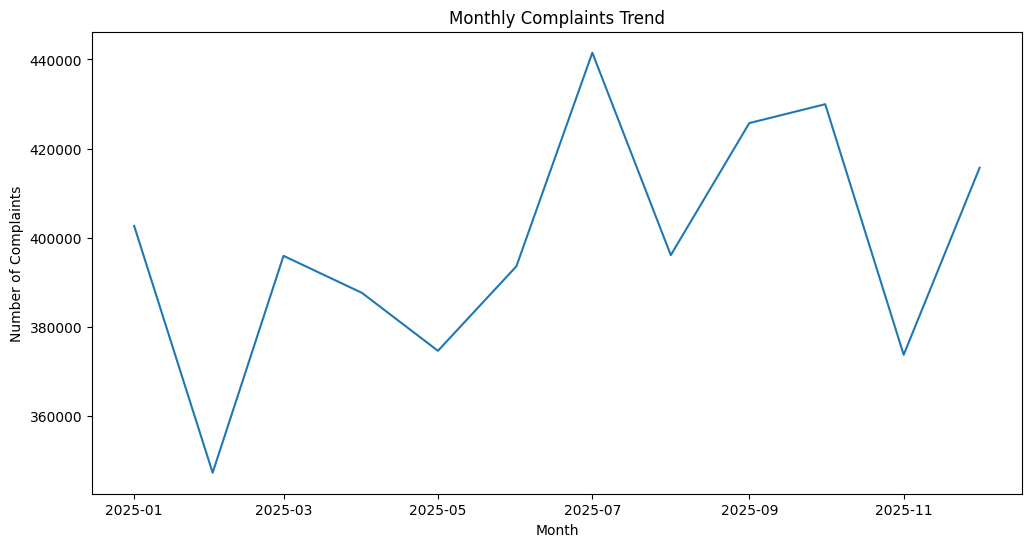

In [97]:
plt.figure(figsize=(12,6))
plt.plot(monthly['month'],monthly['complaints'])
plt.title("Monthly Complaints Trend")   
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.show()

In [98]:
Top_mfr=con.execute("""SELECT manufacturers, count(*) as complaints_cnt from device_complaints group by manufacturers order by complaints_cnt desc """).df()

Text(0, 0.5, 'Number of Complaints')

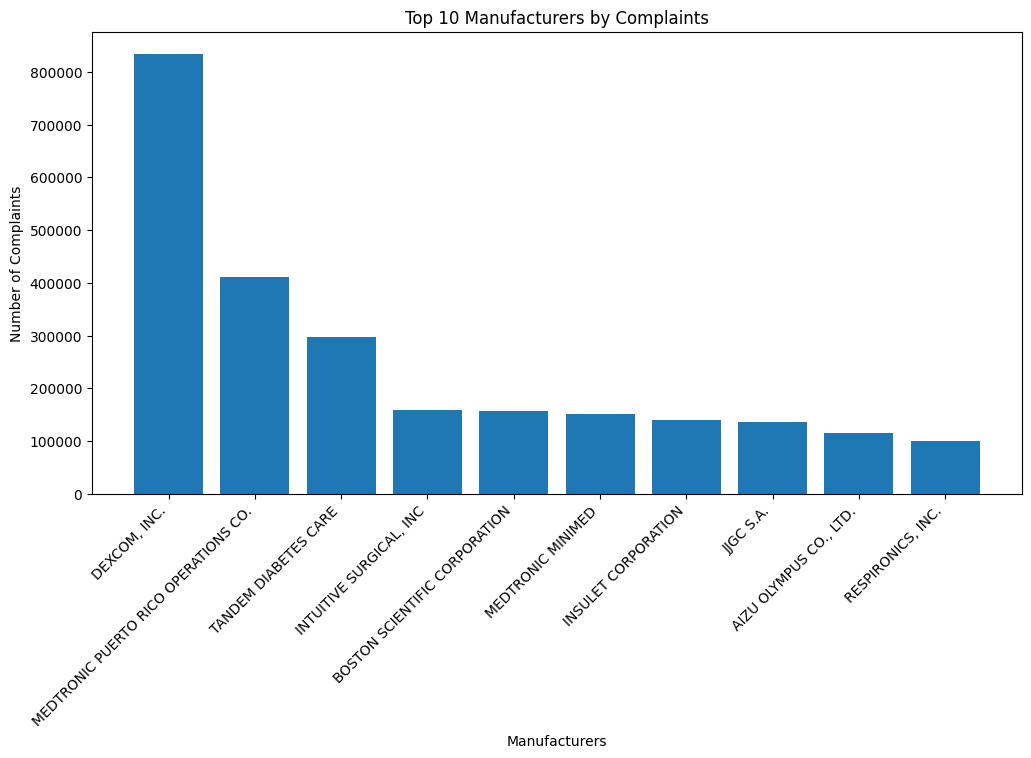

In [106]:
plt.figure(figsize=(12,6))
plt.bar(Top_mfr['manufacturers'][:10],Top_mfr['complaints_cnt'][:10])
plt.title("Top 10 Manufacturers by Complaints") 
plt.xticks(rotation=45,ha='right')
plt.xlabel("Manufacturers")
plt.ylabel("Number of Complaints")  

In [116]:
product_failures = con.execute("""
SELECT 
all_product_codes,
all_brands,
COUNT(*) as complaints
FROM device_complaints
GROUP BY all_product_codes, all_brands
ORDER BY complaints DESC
LIMIT 10
""").df()

Text(0, 0.5, 'Number of Complaints')

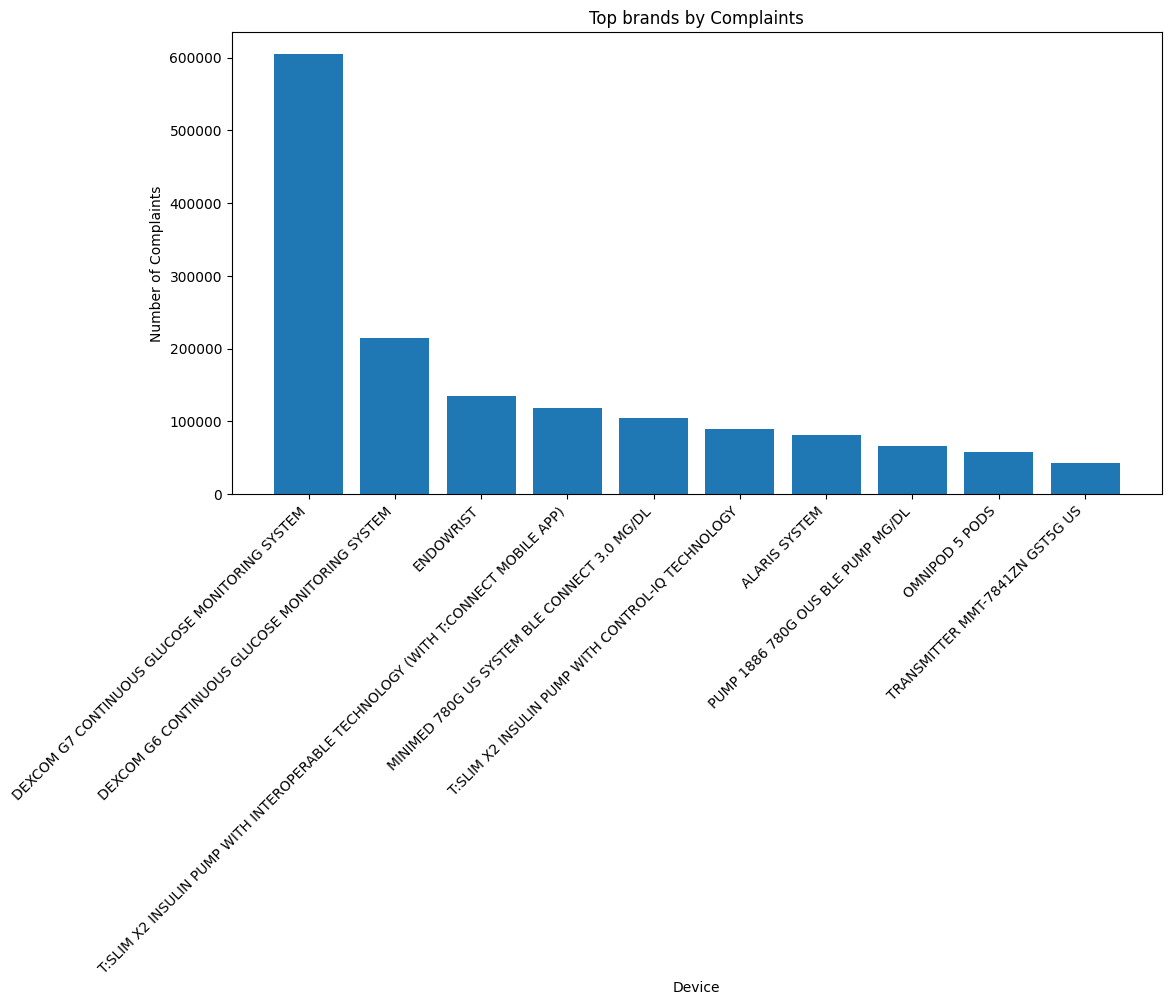

In [119]:
plt.figure(figsize=(12,6))
plt.bar(product_failures['all_brands'],product_failures['complaints'])
plt.title("Top brands by Complaints") 
plt.xticks(rotation=45,ha='right')
plt.xlabel("Device")    
plt.ylabel("Number of Complaints")  

In [120]:
severity = con.execute("""
SELECT max_severity_score, COUNT(*) as cnt
FROM device_complaints
GROUP BY max_severity_score
ORDER BY max_severity_score
""").df()

Text(0, 0.5, 'Number of Complaints')

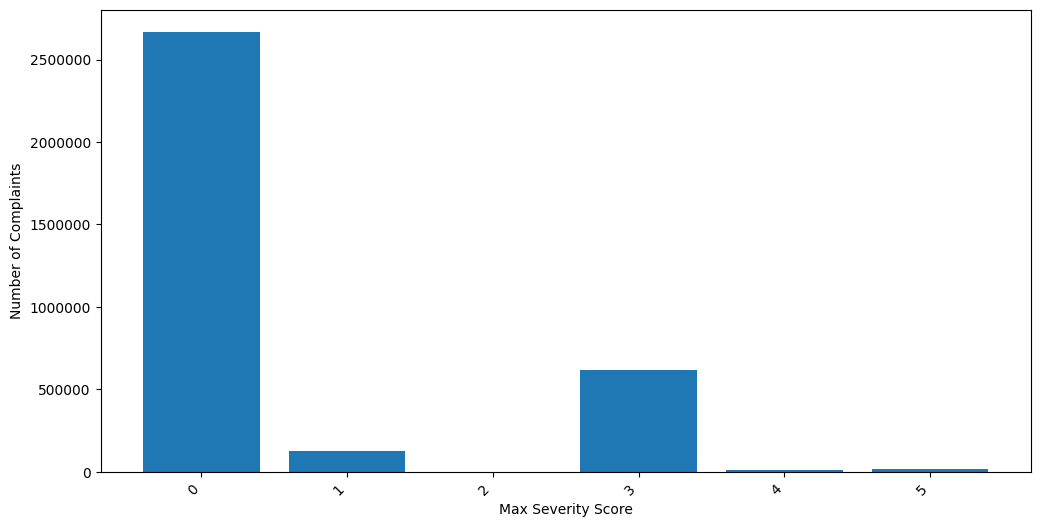

In [123]:
plt.figure(figsize=(12,6))
plt.bar(severity['max_severity_score'], severity['cnt'])
plt.xticks(rotation=45,ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Max Severity Score")        
plt.ylabel("Number of Complaints")

In [127]:
country = con.execute("""
SELECT 
REPORTER_COUNTRY_CODE,
COUNT(*) as complaints
FROM device_complaints
WHERE REPORTER_COUNTRY_CODE IS NOT NULL
GROUP BY REPORTER_COUNTRY_CODE
ORDER BY complaints DESC
LIMIT 20
""").df()

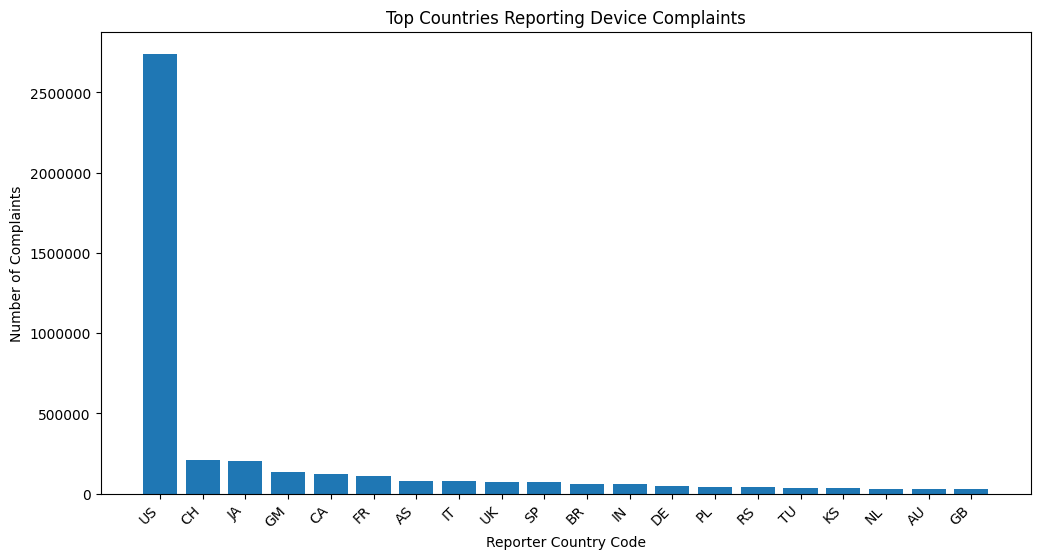

In [129]:
plt.figure(figsize=(12,6))

plt.bar(
    country['REPORTER_COUNTRY_CODE'],
    country['complaints']
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Reporter Country Code")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Number of Complaints")
plt.title("Top Countries Reporting Device Complaints")

plt.show()

In [163]:
text_df = con.execute("""
SELECT complaint_text
FROM device_complaints
WHERE complaint_text IS NOT NULL
""").df()

print(text_df.shape)
text_df.head()

(4675813, 1)


,complaint_text
0,THE BATCH NUMBER COULD NOT BE VERIFIED DUE TO ...
1,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
2,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
3,THE CLINICIAN REPORTS THE IMPLANT WAS INSERTED...
4,THE BATCH NUMBER COULD NOT BE VERIFIED DUE TO ...


In [164]:
text_df['clean_text'] = text_df['complaint_text'].str.lower()

In [165]:
text_df['clean_text'] = text_df['clean_text'].str.replace(r'[^a-zA-Z ]', '', regex=True)

In [187]:
failure_terms = [
    'fracture',
    'broken',
    'crack',
    'leak',
    'burn',
    'overheat',
    'battery',
    'software',
    'malfunction',
    'failure',
    'infection',
    'death',
    'injury',
    'bleeding',
    'explosion',
    'short circuit'
]

In [188]:
failure_counts = {}

for term in failure_terms:
    count = text_df['clean_text'].str.contains(term, na=False).sum()
    failure_counts[term] = count

failure_counts

{'fracture': np.int64(42922),
 'broken': np.int64(104297),
 'crack': np.int64(66277),
 'leak': np.int64(84774),
 'burn': np.int64(16299),
 'overheat': np.int64(8786),
 'battery': np.int64(169331),
 'software': np.int64(92348),
 'malfunction': np.int64(213559),
 'failure': np.int64(415971),
 'infection': np.int64(145468),
 'death': np.int64(101560),
 'injury': np.int64(705312),
 'bleeding': np.int64(21586),
 'explosion': np.int64(875),
 'short circuit': np.int64(1448)}

In [189]:
failure_df = pd.DataFrame(
    failure_counts.items(),
    columns=['failure_term','count']
)

failure_df = failure_df.sort_values(
    by='count',
    ascending=False
)

print(failure_df)

     failure_term   count
12         injury  705312
9         failure  415971
8     malfunction  213559
6         battery  169331
10      infection  145468
1          broken  104297
11          death  101560
7        software   92348
3            leak   84774
2           crack   66277
0        fracture   42922
13       bleeding   21586
4            burn   16299
5        overheat    8786
15  short circuit    1448
14      explosion     875


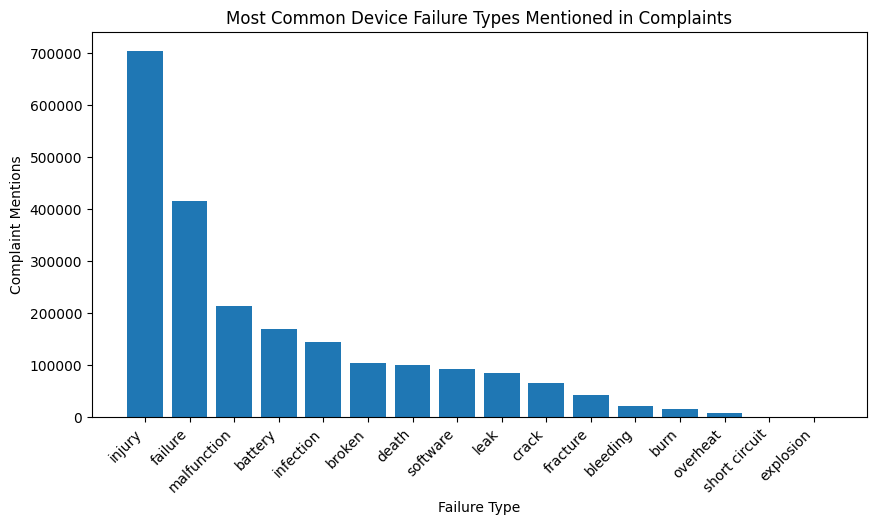

In [190]:
plt.figure(figsize=(10,5))
plt.bar(failure_df['failure_term'], failure_df['count'])

plt.xticks(rotation=45, ha='right')
plt.title("Most Common Device Failure Types Mentioned in Complaints")
plt.xlabel("Failure Type")
plt.ylabel("Complaint Mentions")

plt.show()

In [192]:
con.execute(""" SELECT 
    COUNT(*) as total_2025_mdr_reports,

    SUM(
        CASE 
            WHEN d.MDR_REPORT_KEY IS NULL THEN 1 
            ELSE 0 
        END
    ) as missing_device_records,

    SUM(
        CASE 
            WHEN d.MDR_REPORT_KEY IS NULL THEN 1 
            ELSE 0 
        END
    ) * 100.0 / COUNT(*) as missing_percentage

FROM mdr_recent m
LEFT JOIN device_summary d
ON m.MDR_REPORT_KEY = d.MDR_REPORT_KEY

WHERE YEAR(m.DATE_RECEIVED)=2025 """).df()


,total_2025_mdr_reports,missing_device_records,missing_percentage
0,2725461,541002.0,19.849926


In [204]:
pareto_df = con.execute("""
SELECT 
    manufacturers,
    all_brands,
    COUNT(*) as complaints
FROM device_complaints
WHERE all_brands IS NOT NULL
GROUP BY manufacturers, all_brands
ORDER BY complaints DESC
LIMIT 10
""").df()

pareto_df.head()

,manufacturers,all_brands,complaints
0,"DEXCOM, INC.",DEXCOM G7 CONTINUOUS GLUCOSE MONITORING SYSTEM,604828
1,"DEXCOM, INC.",DEXCOM G6 CONTINUOUS GLUCOSE MONITORING SYSTEM,215102
2,"INTUITIVE SURGICAL, INC",ENDOWRIST,134246
3,TANDEM DIABETES CARE,T:SLIM X2 INSULIN PUMP WITH INTEROPERABLE TECH...,118278
4,MEDTRONIC PUERTO RICO OPERATIONS CO.,MINIMED 780G US SYSTEM BLE CONNECT 3.0 MG/DL,104233


In [205]:
pareto_df['cum_complaints'] = pareto_df['complaints'].cumsum()

pareto_df['cum_percentage'] = (
    pareto_df['cum_complaints'] / pareto_df['complaints'].sum()
) * 100

pareto_df[['all_brands','complaints','cum_percentage']]

,all_brands,complaints,cum_percentage
0,DEXCOM G7 CONTINUOUS GLUCOSE MONITORING SYSTEM,604828,39.821208
1,DEXCOM G6 CONTINUOUS GLUCOSE MONITORING SYSTEM,215102,53.983286
2,ENDOWRIST,134246,62.821895
3,T:SLIM X2 INSULIN PUMP WITH INTEROPERABLE TECH...,118278,70.609188
4,MINIMED 780G US SYSTEM BLE CONNECT 3.0 MG/DL,104233,77.471773
5,T:SLIM X2 INSULIN PUMP WITH CONTROL-IQ TECHNOLOGY,89721,83.378905
6,ALARIS SYSTEM,85271,88.993053
7,PUMP 1886 780G OUS BLE PUMP MG/DL,65734,93.320907
8,OMNIPOD 5 PODS,58005,97.139893
9,TRANSMITTER MMT-7841ZN GST5G US,43441,100.000000


In [210]:
pareto_df['clean_brand'] = pareto_df['all_brands'].replace({
    'DEXCOM G7 CONTINUOUS GLUCOSE MONITORING SYSTEM': 'Dexcom G7',
    'DEXCOM G6 CONTINUOUS GLUCOSE MONITORING SYSTEM': 'Dexcom G6',
    'T:SLIM X2 INSULIN PUMP WITH INTEROPERABLE TECHNOLOGY': 'T-Slim X2 Pump',
    'T:SLIM X2 INSULIN PUMP WITH CONTROL-IQ TECHNOLOGY': 'T-Slim Control-IQ',
    'MINIMED 780G US SYSTEM BLE CONNECT 3.0 MG/DL': 'MiniMed 780G',
    'PUMP 780G OUS BLE PUMP MG/DL': 'MiniMed Pump',
    'ALARIS SYSTEM': 'Alaris System',
    'OMNIPOD 5 PODS': 'Omnipod 5',
    'TRANSMITTER MMT-7841ZN GST5G US': 'Medtronic Transmitter',
    'ENDOWRIST': 'EndoWrist'
})

In [211]:
pareto_df['clean_mfr'] = pareto_df['manufacturers'].replace({
    'DEXCOM, INC.': 'Dexcom',
    'INTUITIVE SURGICAL, INC.': 'Intuitive Surgical',
    'TANDEM DIABETES CARE': 'Tandem',
    'MEDTRONIC PUERTO RICO OPERATIONS CO.': 'Medtronic',
    'CAREFUSION SD': 'CareFusion',
    'INSULET CORPORATION': 'Insulet',
    'MEDTRONIC MINIMED': 'Medtronic'
})

In [223]:
pareto_df['label'] = (
    pareto_df['clean_brand'] + "\n(" + pareto_df['clean_mfr'] + ")"
)
pareto_df['clean_brand'] = pareto_df['clean_brand'].replace({
    'Dexcom G7': 'G7',
    'Dexcom G6': 'G6'
})

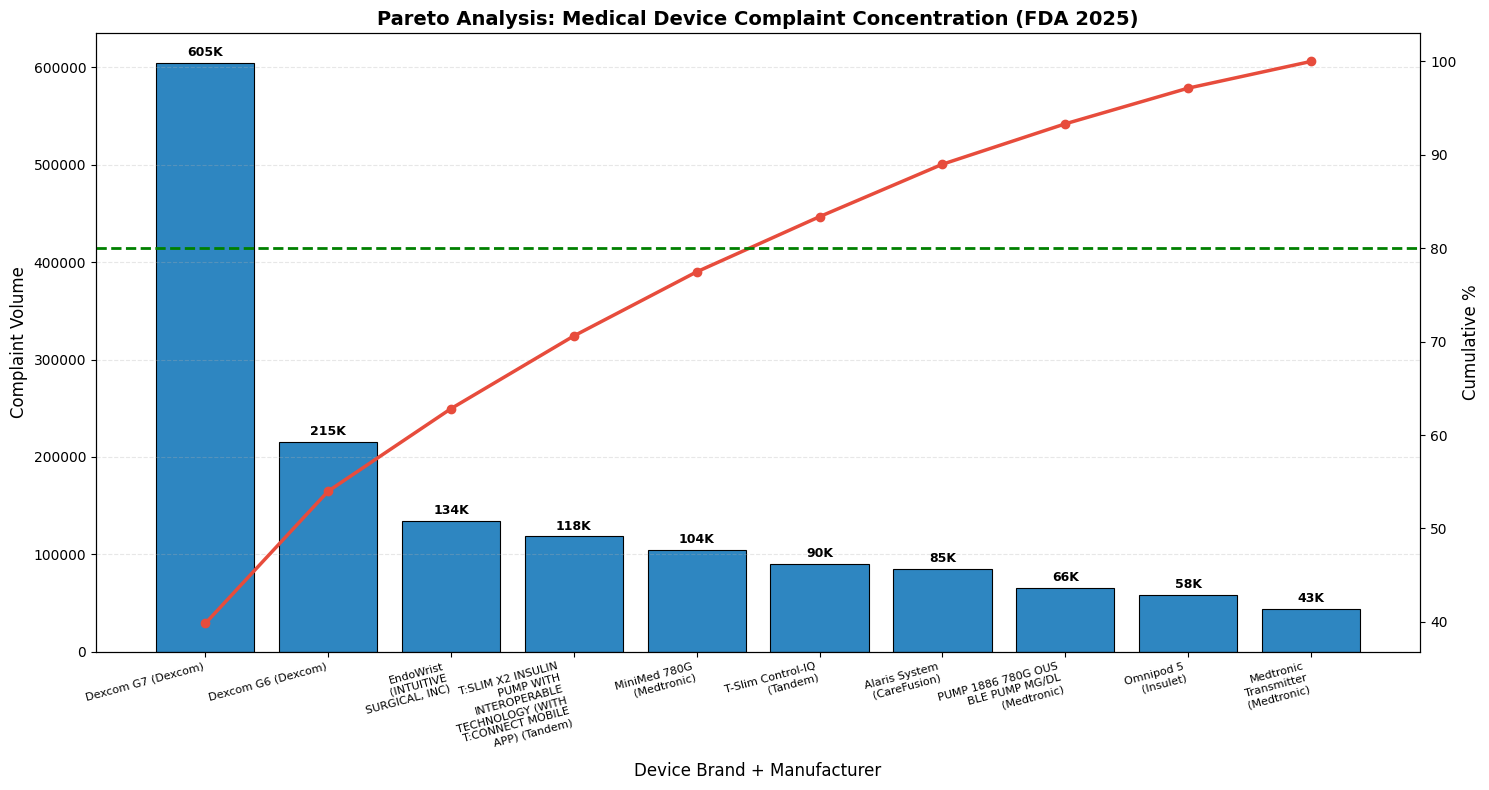

In [224]:
import textwrap

# wrap long labels nicely
pareto_df['wrapped_label'] = pareto_df['label'].apply(
    lambda x: "\n".join(textwrap.wrap(x, width=18))
)

fig, ax1 = plt.subplots(figsize=(15,8))

# cleaner darker blue
bars = ax1.bar(
    pareto_df['wrapped_label'],
    pareto_df['complaints'],
    color='#2E86C1',
    edgecolor='black',
    linewidth=0.8
)

# bar values
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 7000,
        f'{height/1000:.0f}K',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_ylabel("Complaint Volume", fontsize=12)
ax1.set_xlabel("Device Brand + Manufacturer", fontsize=12)

ax1.set_title(
    "Pareto Analysis: Medical Device Complaint Concentration (FDA 2025)",
    fontsize=14,
    fontweight='bold'
)

# keep labels horizontal now
plt.xticks(
    rotation=15,ha='right',
    fontsize=8
)

# cumulative line
ax2 = ax1.twinx()

ax2.plot(
    pareto_df['wrapped_label'],
    pareto_df['cum_percentage'],
    color='#E74C3C',
    marker='o',
    linewidth=2.5
)

ax2.set_ylabel("Cumulative %", fontsize=12)

# 80% threshold line
ax2.axhline(
    y=80,
    color='green',
    linestyle='--',
    linewidth=2
)

# cleaner grid
ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()